# Outlier Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = pd.read_csv('../datasets_globelEnv/Iris.csv')

iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("\nDataset Information:")
print(iris.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None


In [5]:
numeric_columns = iris.select_dtypes('float').columns
numeric_columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='str')

## VISUALIZE DATA USING HISTOGRAMS

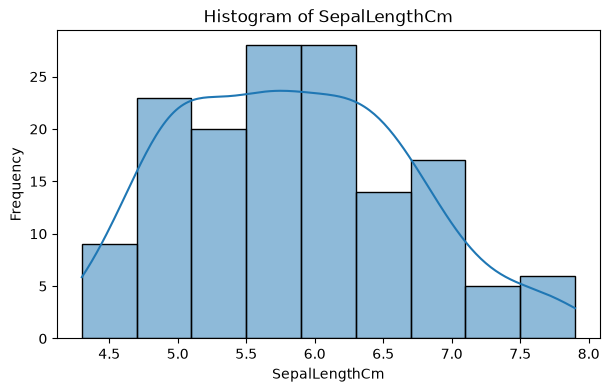

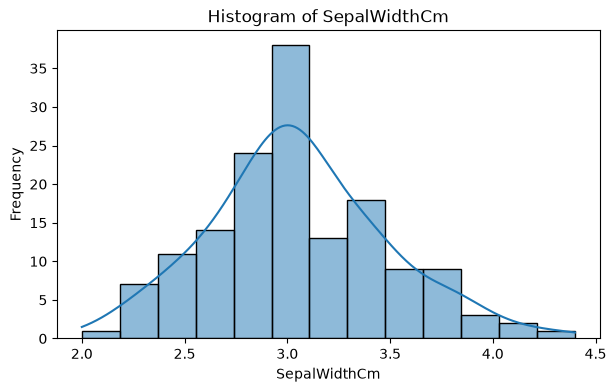

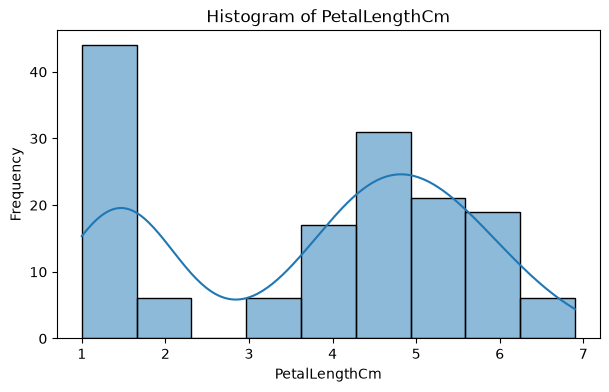

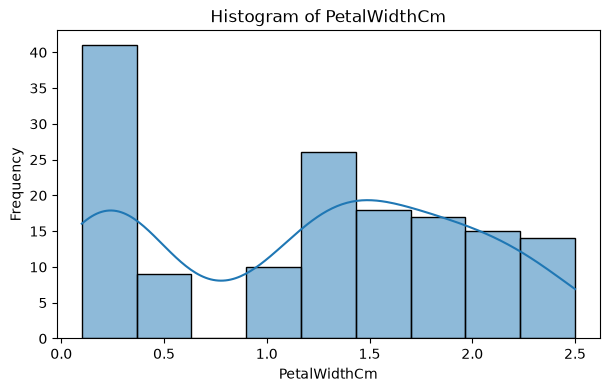

In [6]:
for column in numeric_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=iris,
        x=column,
        kde=True
    )

    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()


## VISUALIZE OUTLIERS USING BOX PLOTS

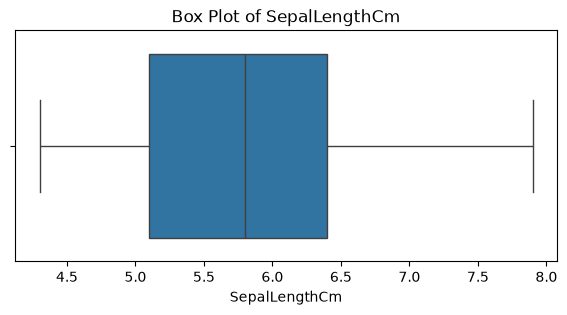

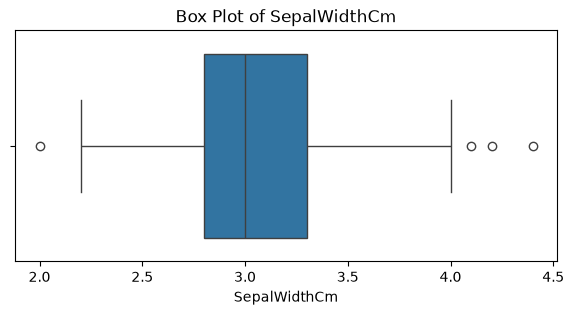

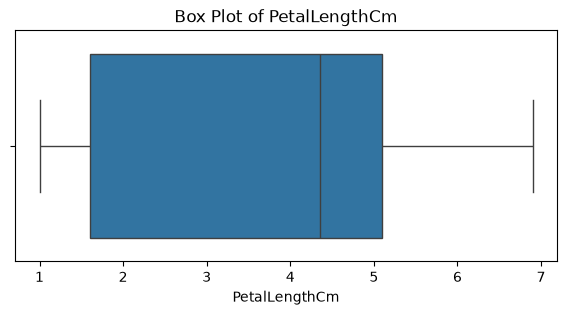

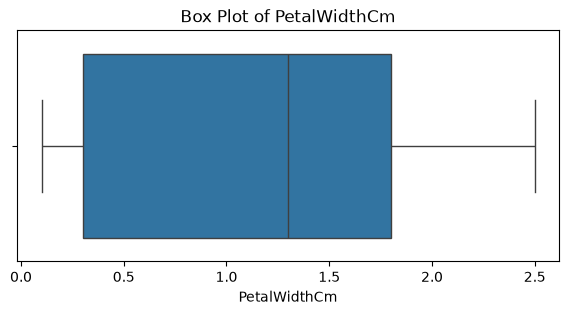

In [7]:
for column in numeric_columns:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        data=iris,
        x=column
    )

    plt.title(f"Box Plot of {column}")

    plt.show()

# DETECT OUTLIERS USING THE IQR METHOD

IQR = Q3 - Q1

Lower Boundary = Q1 - 1.5 * IQR

Upper Boundary = Q3 + 1.5 * IQR

In [8]:
for column in numeric_columns:

    print(f"\n----- {column} -----")

    Q1 = iris[column].quantile(0.25)

    Q3 = iris[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    outliers = iris[
        (iris[column] < lower_bound) |
        (iris[column] > upper_bound)
    ]

    print("Number of Outliers:", len(outliers))

    # Show detected outlier values
    print("Outlier Values:")
    print(outliers[column].values)



----- SepalLengthCm -----
Q1: 5.1
Q3: 6.4
IQR: 1.3000000000000007
Lower Bound: 3.1499999999999986
Upper Bound: 8.350000000000001
Number of Outliers: 0
Outlier Values:
[]

----- SepalWidthCm -----
Q1: 2.8
Q3: 3.3
IQR: 0.5
Lower Bound: 2.05
Upper Bound: 4.05
Number of Outliers: 4
Outlier Values:
[4.4 4.1 4.2 2. ]

----- PetalLengthCm -----
Q1: 1.6
Q3: 5.1
IQR: 3.4999999999999996
Lower Bound: -3.649999999999999
Upper Bound: 10.349999999999998
Number of Outliers: 0
Outlier Values:
[]

----- PetalWidthCm -----
Q1: 0.3
Q3: 1.8
IQR: 1.5
Lower Bound: -1.95
Upper Bound: 4.05
Number of Outliers: 0
Outlier Values:
[]


In [ ]:
column = "SepalWidthCm"

Q1 = iris[column].quantile(0.25)
Q3 = iris[column].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sepal_width_outliers = iris[
    (iris[column] < lower_bound) |
    (iris[column] > upper_bound)
]

print("Complete rows containing Sepal Width outliers:")
print(sepal_width_outliers)


Complete rows containing Sepal Width outliers:
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
15  16            5.7           4.4            1.5           0.4   
32  33            5.2           4.1            1.5           0.1   
33  34            5.5           4.2            1.4           0.2   
60  61            5.0           2.0            3.5           1.0   

            Species  
15      Iris-setosa  
32      Iris-setosa  
33      Iris-setosa  
60  Iris-versicolor  
